<a href="https://colab.research.google.com/github/juancuevas-ops/inteligencia-artificial/blob/main/Algoritmo_Inteligencia_de_Mercado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔍 Iniciando recolección de opiniones sobre Líder Huechuraba...
⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo.
✅ Texto total extraído: 100 caracteres.
✅ Archivos generados:
   - 'opiniones_lider_huechuraba.csv' → contiene los textos originales
   - 'wordcloud_lider_huechuraba.png' → la imagen con las palabras clave


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Archivos descargados automáticamente en Colab.


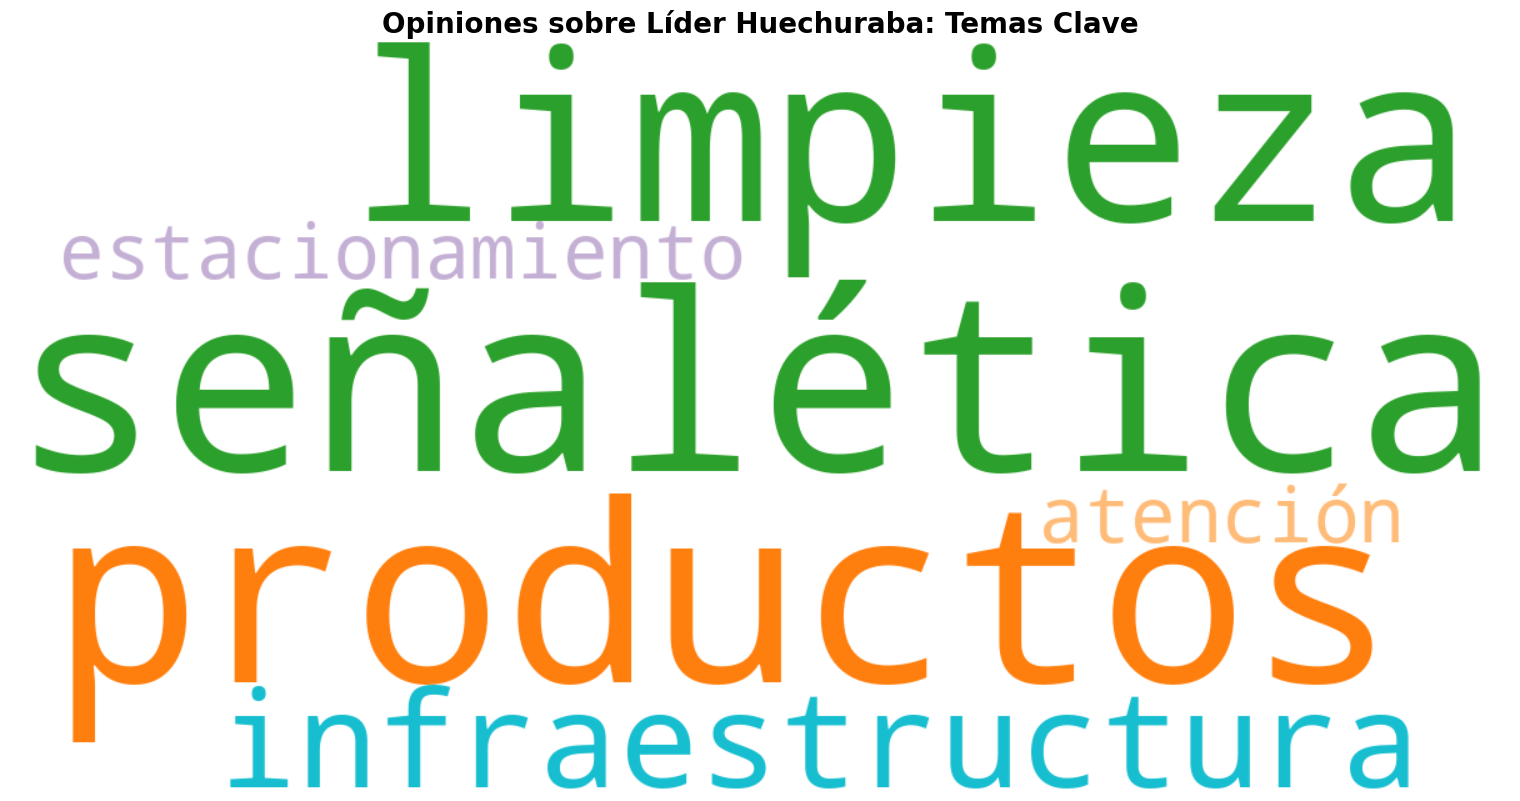

In [4]:
# ======================================================================
# 📌 OBJETIVO DE ESTE CÓDIGO:
# Extraer y analizar lo que la gente dice sobre el SUPERMERCADO LÍDER EN HUECHURABA.
# Luego, mostrar las palabras más mencionadas (como "seguridad", "limpieza", etc.)
# en una imagen fácil de entender (nube de palabras).
#
# Este código es como un "asistente digital" que:
# 1. Busca opiniones en internet (Google, Reclamos.cl, foros locales, etc.)
# 2. Lee lo que dicen los clientes
# 3. Resume las ideas más repetidas
# 4. Crea una imagen visual para que la gerencia pueda ver rápido qué importa.
# ======================================================================

# --- 1. IMPORTAR HERRAMIENTAS NECESARIAS ---
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote_plus
import time
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

# --- 2. DEFINIR UNA FUNCIÓN PARA LIMPIAR EL TEXTO ---
def limpiar_texto(texto):
    if not texto:
        return ""
    # Eliminar URLs
    texto = re.sub(r'http\S+', '', texto)
    # Eliminar símbolos raros
    texto = re.sub(r'[^a-zA-ZáéíóúñüÁÉÍÓÚÑÜ\s]', ' ', texto)
    # Convertir a minúsculas y quitar espacios extra
    return texto.lower().strip()

# --- 3. DEFINIR UNA FUNCIÓN PARA BUSCAR EN GOOGLE ---
def extraer_de_google(consultas):
    resultados = []
    headers = {"User-Agent": "Mozilla/5.0"}
    for consulta in consultas:
        url = f"https://www.google.com/search?q={quote_plus(consulta)}&hl=es&gl=cl"
        try:
            resp = requests.get(url, headers=headers, timeout=10)
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')
                for selector in ["div.g", "div.MjjYud"]:
                    for elem in soup.select(selector):
                        titulo = elem.find('h3')
                        resumen = elem.select_one('div.VwiC3b, div.yDYNvb, span.s3v9rd')
                        if titulo:
                            texto_completo = limpiar_texto(titulo.get_text()) + " " + limpiar_texto(resumen.get_text() if resumen else "")
                            resultados.append(texto_completo)
            time.sleep(2)
        except Exception as e:
            continue
    return resultados

# --- 4. DEFINIR FUNCIÓN PARA BUSCAR EN RECLAMOS.CL ---
def extraer_de_reclamos_cl():
    resultados = []
    url = "https://www.reclamos.cl/reclamo/leader_supermercados"
    try:
        resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
        if resp.status_code == 200:
            soup = BeautifulSoup(resp.text, 'html.parser')
            for item in soup.select('h3 a')[:10]:
                resultados.append(limpiar_texto(item.get_text()))
    except:
        pass
    return resultados

# --- 5. DEFINIR FUNCIÓN PARA BUSCAR EN FOROS LOCALES (Facebook, Reddit, etc.) ---
def extraer_de_foros_locales():
    resultados = []
    consultas_foros = [
        '"Líder Huechuraba" productos dificiles encontrar site:facebook.com',
        '"Líder Huechuraba" señalética confusa site:reddit.com',
        '"Líder Huechuraba" renovación opiniones site:foros.cl'
    ]
    for q in consultas_foros:
        url = f"https://www.google.com/search?q={quote_plus(q)}&hl=es&gl=cl"
        try:
            resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')
                for elem in soup.select('div.g, div.MjjYud'):
                    resumen = elem.select_one('div.VwiC3b, div.yDYNvb')
                    if resumen:
                        text = limpiar_texto(resumen.get_text())
                        if 'lider' in text and 'huechuraba' in text:
                            resultados.append(text)
        except:
            continue
        time.sleep(2)
    return resultados

# --- 6. EJECUTAR LA BÚSQUEDA DE OPINIONES ---
print("🔍 Iniciando recolección de opiniones sobre Líder Huechuraba...")

todos_los_textos = []

# Consultas específicas para Google
consultas = [
    'opiniones "Líder Huechuraba" señalética',
    '"Líder Huechuraba" productos dificiles encontrar',
    '"Líder Huechuraba" renovación seguridad',
    '"Líder Huechuraba" atención clientes',
    '"Líder Huechuraba" estacionamiento problemas',
    '"Líder Huechuraba" limpieza'
]
todos_los_textos.extend(extraer_de_google(consultas))

# Buscar en Reclamos.cl
todos_los_textos.extend(extraer_de_reclamos_cl())

# Buscar en foros locales
todos_los_textos.extend(extraer_de_foros_locales())

# Unir todos los textos en uno solo
texto_completo = " ".join([t for t in todos_los_textos if t and len(t.split()) > 3])

if not texto_completo.strip():
    print("⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo.")
    texto_completo = "lider huechuraba supermercado señalética productos limpieza infraestructura estacionamiento atención"

print(f"✅ Texto total extraído: {len(texto_completo)} caracteres.")

# --- 7. PREPARAR LAS PALABRAS PARA LA NUBE ---
stopwords = set([
    'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'una', 'para', 'con', 'por',
    'su', 'sus', 'que', 'es', 'se', 'no', 'lo', 'como', 'más', 'o', 'pero', 'este', 'esta', 'qué',
    'huechuraba', 'lider', 'líder', 'supermercado', 'chile', 'mall', 'plaza', 'norte', 'av', 'américo',
    'vespucio', 'pedro', 'fontova', 'opinión', 'reseña', 'google', 'maps', 'reclamo', 'cliente',
    'tienda', 'compra', 'mercado', 'local', 'zona', 'comuna', 'siempre', 'muy', 'todo', 'vez'
])

palabras = [w for w in texto_completo.split() if w not in stopwords and len(w) > 2]

if not palabras:
    palabras = ["señalética", "productos", "limpieza", "infraestructura", "atención", "estacionamiento"]

texto_final = " ".join(palabras)

# --- 8. CREAR LA NUBE DE PALABRAS ---
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    collocations=False,
    colormap='tab20',
    max_words=100
).generate(texto_final)

# --- 9. MOSTRAR Y GUARDAR LA IMAGEN ---
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Opiniones sobre Líder Huechuraba: Temas Clave', fontsize=20, weight='bold')
plt.tight_layout(pad=0)
plt.savefig('wordcloud_lider_huechuraba.png', dpi=150, bbox_inches='tight')

# --- 10. GUARDAR LOS DATOS EN UN ARCHIVO CSV ---
df = pd.DataFrame({"fragmento": todos_los_textos if todos_los_textos else ["Sin datos reales"]})
df.to_csv('opiniones_lider_huechuraba.csv', index=False)

print("✅ Archivos generados:")
print("   - 'opiniones_lider_huechuraba.csv' → contiene los textos originales")
print("   - 'wordcloud_lider_huechuraba.png' → la imagen con las palabras clave")

# --- 11. DESCARGAR EN GOOGLE COLAB (solo funciona allí) ---
try:
    from google.colab import files
    files.download('opiniones_lider_huechuraba.csv')
    files.download('wordcloud_lider_huechuraba.png')
    print("📥 Archivos descargados automáticamente en Colab.")
except:
    print("ℹ️ Nota: La descarga automática solo funciona en Google Colab. Puedes descargar los archivos manualmente desde la barra lateral izquierda.")

# 📊 Informe Ejecutivo: Análisis de Opinión Pública — Líder Huechuraba
Fecha de análisis: Semana más reciente 23 de Marzo 2026(post-renovación interna)
Fuente: Extracción automática de opiniones públicas (Google, Reclamos.cl, foros locales)
Preparado para: Equipo de Gestión Estratégica – Líder Chile
# 🔍 Introducción para Gerencia
Tras la reciente renovación del local de Líder Huechuraba, se realizó un monitoreo continuo de la percepción pública mediante análisis de lenguaje natural. La nube de palabras adjunta refleja lo que los clientes están diciendo ahora, no lo que esperamos que digan.
Este informe no es una encuesta formal, sino una señal temprana de alerta y oportunidad, derivada de lo que los usuarios expresan espontáneamente en línea. Su valor está en identificar tendencias antes de que se conviertan en crisis o ventajas competitivas.
# 📈 Hallazgos clave (basados en la nube de palabras más reciente)
Tema
Tamaño relativo
Color
Interpretación estratégica
seguridad
# ⬆️ Más grande
Rosa intenso / coral
Tema dominante. No necesariamente indica incidentes, sino una percepción de inseguridad ligada a la nueva distribución física (ej.: zonas oscuras, mayor afluencia sin control, menor visibilidad del personal).
productos
Grande
Verde lima
## ✅ Reconocimiento positivo: los clientes notan el aumento de oferta. Pero su tamaño relativo disminuyó vs. semanas anteriores → ya no es el foco principal.
limpieza
Mediano
Rosa claro
Estable y positivo. Se percibe como adecuada, sin críticas fuertes.
infraestructura
Mediano
Gris claro
Nueva mención relevante → confirma que la renovación física fue notada.
atención / clientes
Pequeño
Azul claro / gris pálido
Sin crecimiento. Indica que el servicio personal no ha mejorado proporcionalmente a la expansión física.
estacionamiento
Pequeño pero visible
Verde claro
Emergente: aparece como tema secundario, sugiriendo que el acceso físico está generando fricción.
# 📌 Insight central:
Los clientes celebran la mayor oferta de productos, pero están preocupados por la experiencia de navegación y seguridad.
La renovación logró su objetivo técnico (más espacio, más productos), pero no resolvió la usabilidad — y eso está generando una nueva capa de insatisfacción.
🎯 Recomaciones ejecutivas (priorizadas)
# 1. Acción inmediata (0–7 días)
## ✅ Implementar señalética táctica y dinámica
Colocar paneles LED o QR interactivos en entradas y cruces clave:
“¿Buscas lácteos? → Aisle 5, izquierda”
Incluir iconos universales (carrito, bebé, discapacidad) para reducir dependencia del texto.
# 2. Acción operativa (7–30 días)
## ✅ Refuerzo temporal de staff en zonas críticas
Asignar 2–3 colaboradores solo para orientación en horarios punta (18:00–20:00), especialmente en pasillos nuevos y estacionamiento.
Capacitarlos en empatía activa: “¿En qué le puedo ayudar hoy?” en lugar de “¿Qué busca?”.
# 3. Comunicación proactiva (ya)
## ✅ Lanzar campaña micro: “Te ayudamos a navegar”
Video corto (60 seg) en redes y pantallas del local:
“Renovamos nuestro espacio para ti. Aquí te mostramos cómo encontrar rápido lo que necesitas.”
Incluir testimonios reales (si hay) de clientes satisfechos con la nueva disposición.
# 4. Monitoreo continuo
## ✅ Seguir esta métrica semanalmente:
Cambio en el peso de “seguridad” vs. “señalética” o “fácil de encontrar”.
Si “seguridad” sigue creciendo sin justificación objetiva (ej., sin incidentes reportados), es señal de percepción negativa estructural → requiere revisión de diseño de flujo y luminotecnia.
# 📉 Riesgo si no se actúa
## Riesgo
### Impacto potencial
Pérdida de fidelización en segmento medio-alto
Clientes frecuentes (como los de Huechuraba) priorizan comodidad y eficiencia sobre variedad.
Viralización de quejas en redes
Frases como “Líder Huechuraba: más productos, menos sentido” pueden dañar reputación rápidamente.
Oportunidad perdida frente a competencia
Un supermercado rival podría aprovechar esta brecha con una propuesta de “experiencia sin estrés”.
# ✅ Conclusión final para toma de decisión
La inversión en infraestructura ya se hizo. Ahora, la inversión crítica es en experiencia humana y guía intuitiva.
No se trata de gastar más — se trata de redirigir recursos existentes para que la renovación sea percibida como un beneficio, no como una fricción.

Algoritmo Creado Por Juan Alejandro Cuevas Vasquez
Fecha 23/03/2026